# Puzzle

### This Week’s Fiddler
For her photography show, Frederica Fiddleria attaches a light to a point on the circumference of a circular wheel with a radius of 1 meter. She points a camera at the wheel and, during a single long exposure, rolls the wheel for one revolution along the ground.

When she develops the film, she is curious about the path the light took as the wheel rolled. What is the length of this path?

### This Week’s Extra Credit
For her next show, Frederica wants to mix things up. Instead of placing the light on the circumference of the wheel, she will pick a random point inside the circle. (Before you ask, let me clarify what “random” means here: Any two regions with the same area are equally likely to contain the point.)

As before, she will roll the wheel for one revolution along the ground and capture the motion with a single long exposure on her camera. On average, what can she expect the length of the path to be?

# Solution

### Setup
Let $R$ be the radius of the wheel, and let the selected point be at a distance $r$ from the center.

Let the origin be at the center of the wheel in it's starting position.

Since we are rolling one full revolution, it doesn't matter what angle we position the point at, so we can pick a convenient point, say vertically below the origin.

Now, when the wheel rolls by an angle $t$, the contact point on the ground will move by Rt, and so the center will also move horizontally by $Rt$. Additionally, the point will rotate about the center.


### Coordinates
So, the point's x-y position can be described as function of $t$: 

$(x,y) = (Rt - r sin(t), -r cos(t))$

Now the distance moved through a small rotation $dt$ can be calculated by:

$ dx/dt = R - r cos(t) $

$ dy/dt = r sin(t) $

$ dx = dt (R - r cos(t)) $

$ dy = dt (r sin(t)) $

And the distance ds:

$ ds = \sqrt{ dx^2 + dy^2} $

$ ds = dt \sqrt{ R^2 - 2Rr cos(t) + r^2 cos^2(t) + r^2 sin^2(t) } $

$ ds = dt \sqrt{ R^2 - 2Rr cos(t) + r^2 } $

$ ds = dt R \sqrt{ 1 - 2(r/R) cos(t) + (r/R)^2 } $


### Distance

So, the total distance can be calculated as the integral:

$ S = \int ds$  

$ S = \int_0^{2\pi} dt R \sqrt{ 1 - 2(r/R) cos(t) + (r/R)^2 } $

And naming $k = r/R$

$ S = R \int_0^{2\pi} dt \sqrt{ 1 - 2k cos(t) + k^2 } $

### Fiddler Integral

For the fiddler, R = 1, r = 1, k = 1. So, the integral simplifies to:

$ S = \int_0^{2\pi} dt \sqrt{ 2 - 2 cos(t)} $

$ S = \sqrt{2} \int_0^{2\pi} dt \sqrt{ 1 - cos(t)} $

$ S = \sqrt{2} \int_0^{2\pi} dt \sqrt{ 1 - (cos^2(t/2) - sin^2(t/2))} $

$ S = \sqrt{2} \int_0^{2\pi} dt \sqrt{ 1 - cos^2(t/2) + sin^2(t/2)} $

$ S = \sqrt{2} \int_0^{2\pi} dt \sqrt{ sin^2(t/2) + sin^2(t/2)} $

$ S = \sqrt{2} \int_0^{2\pi} dt \sqrt{ 2 sin^2(t/2)} $

$ S = 2 \int_0^{2\pi} dt (sin(t/2)) $

$ S = 2 | -2cos(t/2) |_0^{2\pi} $

$ S = -4 [cos(pi) - cos(0)] $

$ S = 8 $

Wow, that's surprisingly simple.

### Extra Credit Integral

Going back to the previous formula:

$ S(k) = R \int_0^{2\pi} dt \sqrt{ 1 - 2k cos(t) + k^2 } $

$ S(k) = R \int_0^{2\pi} dt \sqrt{ cos^2(t) + sin^2(t) - 2k cos(t) + k^2 } $

$ S(k) = R \int_0^{2\pi} dt \sqrt{ (cos(t) - k)^2 + sin^2(t)} $

I am not seeing a clever way to solve this integral. So, I'm switching to an numerical approach.

### Extra Credit Numerical

In [8]:
from scipy.integrate import quad, nquad
from math import pi, sin, cos, sqrt, isclose

# $ S = \int_0^{2\pi} dt R \sqrt{ 1 - 2(r/R) cos(t) + (r/R)^2 } $
def path_length(r, R=1, angle=2*pi, verbose=False):
    def integrand(t):
        constant_term = R*R + r*r
        variable_term = 2*R*r*cos(t)
        return sqrt(constant_term - variable_term)
    quad_result = quad(integrand, 0, angle)
    if verbose:
        print(f">> Integration result: {quad_result[0]}, Estimated error: {quad_result[1]}")
    return quad_result[0]

fiddler_answer = path_length(1, verbose=True)
print(f"Fiddler's answer: {fiddler_answer}")

assert isclose(fiddler_answer, 8, rel_tol=1e-9), f"Expected 8.0, got {fiddler_answer}"

>> Integration result: 8.0, Estimated error: 8.881784197001252e-14
Fiddler's answer: 8.0


In [9]:
def expected_path_length(R=1, angle=2*pi):
    def integrand(r):
        plen = path_length(r, R, angle, verbose=False) 
        plen_scaled_by_area = plen * 2 * pi * r
        return plen_scaled_by_area
    integrated_value = quad(integrand, 0, R)[0]
    normalized_value = integrated_value / (pi * R * R)
    return normalized_value

extra_credit_answer = expected_path_length()
print(f"Extra credit answer: {extra_credit_answer}")

# Simplified version of the expected path length calculation, cancelling out the area normalization factor
def expected_path_length_alt(R=1, angle=2*pi, verbose=False):
    def integrand(r):
        plen = path_length(r, R, angle, verbose=False) 
        plen_scaled_by_area = plen * 2 * r / R**2  # Normalizing by area factor
        return plen_scaled_by_area
    quad_result = quad(integrand, 0, R)
    if verbose:
        print(f">> Integration result: {quad_result[0]}, Estimated error: {quad_result[1]}")
    return quad_result[0]

extra_credit_answer = expected_path_length_alt(verbose=True)
print(f"Extra credit answer: {extra_credit_answer}")

Extra credit answer: 7.111111111105666
>> Integration result: 7.111111111105666, Estimated error: 4.2681877489808066e-08
Extra credit answer: 7.111111111105666


Okay, so we have an answer, and very likely the exact answer is 64/9 = 7.1111...

Maybe we revisit the analytical approach tomm?

### Analytical revisited.

In the most basic form:

$ S(r) = \int_0^{2\pi} dt \sqrt{ R^2 + r^2 - 2Rr cos(t) } $

Can be rewritten as:

$ S(r) = \sqrt{2rR} \int_0^{2\pi} dt \sqrt{ ((R^2 + r^2)/2Rr) -  cos(t) } $

Now, calling $a = ((R^2 + r^2)/2Rr)$, we can put this in a more standard-ish form:

$ S(r) = \sqrt{2rR} \int_0^{2\pi} dt \sqrt{ a -  cos(t) } $

Also note that $a$ is of the form AM/GM, so we should always have $a >=1$, for $r > 0$.

Wolfram Alpha can solve this indefinite integral:
https://www.wolframalpha.com/input?i=integral+of+sqrt%28a+-+cos%28x%29%29

But gets stuck on the definite integral:
https://www.wolframalpha.com/input?i=integral+of+sqrt%28a+-+cos%28x%29%29+from+x%3D0+to+x%3D2pi

But we can try to do the definite integral part of it ourselves. From the links above:

$ I = \int dx \sqrt{a - cos(x)} = \frac{2 \sqrt{a - cos(x)}}{\sqrt{(a - cos(x))/(a - 1)}} E(x/2 | -2/(a - 1)) + C $, where $E(x|m)$ is an elliptic integral of the second kind with parameter $m = k^2$

Actually, I am not sure why the 2 $\sqrt{a - cos(x)}$ parts don't just cancel out, to give:

$ I = \int dx \sqrt{a - cos(x)} = 2 \sqrt{a - 1} E(x/2 | -2/(a - 1)) + C $, where $E(x|m)$ is an elliptic integral of the second kind with parameter $m = k^2$

Update: that link actually does this simplification lower down, for positive a, x, which we have.


At x=0, $cos(0) = 1$

$ I(0) = 2 \sqrt{a-1} \times E(0 | -2/(a-1)) $

Looking at https://mathworld.wolfram.com/EllipticIntegraloftheSecondKind.html , we can see that E(0|*) will be 0 because it is an integral from zero to zero. So,

$I(0) = 0$


At x = 2 pi, $cos(2 \pi) = -1$

$ I(2\pi) = 2 \sqrt{a-1} \times E(pi | -2/(a-1)) $

---

I am lost.

Also, I am thinking that with Elliptic Integrals involved, there is unlikely to be a closed form solution, at least one that *I* can be confident of. So, dropping this for now.

### Visuals

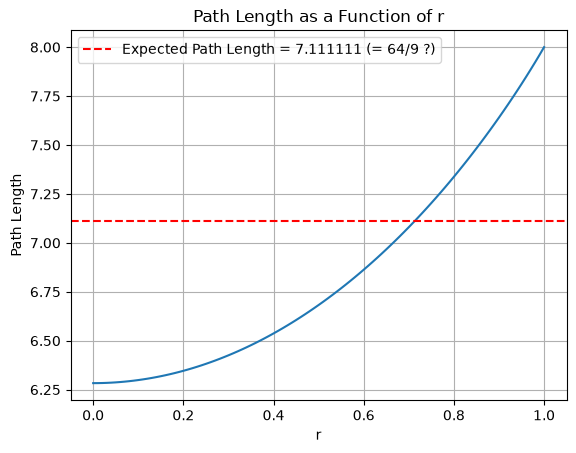

In [10]:
# Plot the path length as a function of r
import matplotlib.pyplot as plt

r_values = [i/100 for i in range(101)]
path_lengths = [path_length(r, verbose=False) for r in r_values]

plt.plot(r_values, path_lengths)
plt.title("Path Length as a Function of r")
plt.xlabel("r")
plt.ylabel("Path Length")
plt.axhline(y=7.111111111105666, color='r', linestyle='--', label='Expected Path Length = 7.111111 (= 64/9 ?)')
plt.legend()
plt.grid()
plt.show()

While the difference-from-average areas don't look equal, that's because there is an uneven weighting by the $2 \pi r$ factor that's not shown here.

And here's a interactive visualization of the wheel, point, and curve.

https://www.desmos.com/calculator/j02vxh2abr

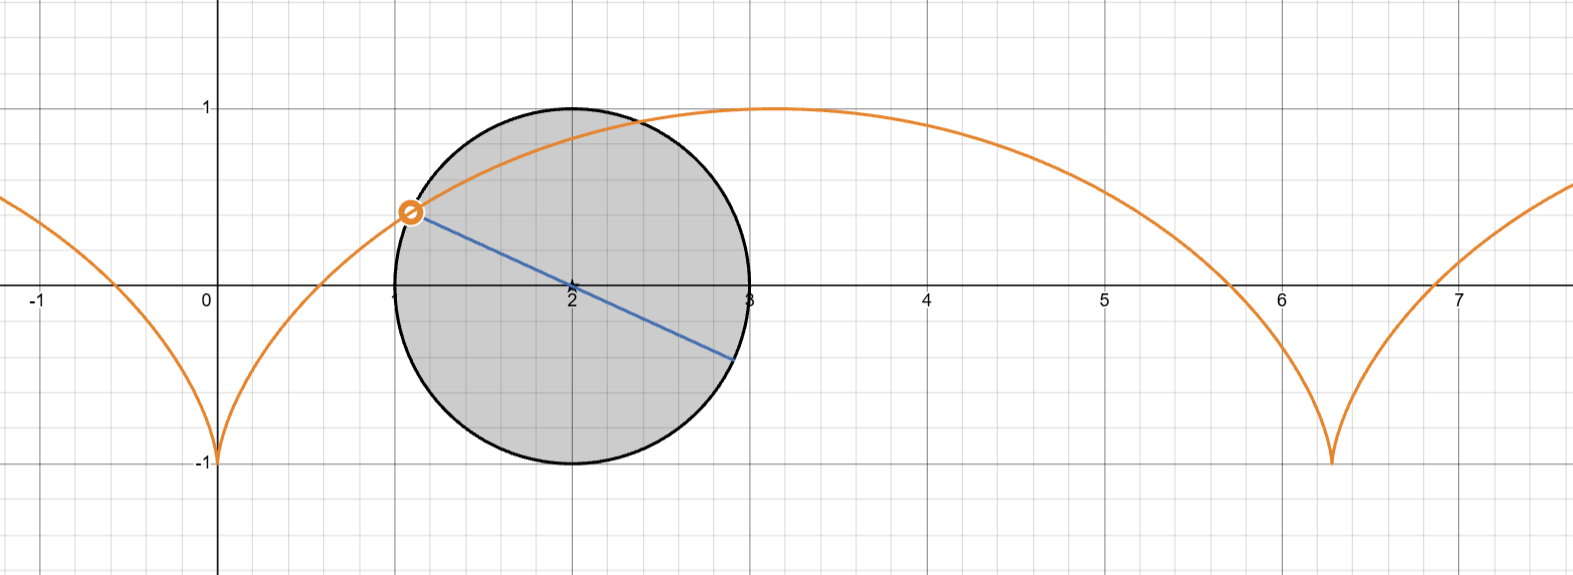



# Conclusion.

Fiddler Answer is 8 !!!

Extra credit answer is 7.1111111, possibly = 64/9.

The interactive demo ( https://www.desmos.com/calculator/j02vxh2abr ) is pretty fun to play with.